In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [194]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]
coords, tets = TesselationCore.tesselate(points3d)
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
simplex = simplices[1]


4×3 adjoint(::Matrix{Float64}) with eltype Float64:
 0.374976  0.928975  0.968811
 0.837     0.938898  0.895648
 0.735183  0.747686  0.742009
 0.540187  0.986108  0.606363

In [ ]:
struct BVHTree #TODO change with abstraction - BVH Node
    depth::Int
    rightChild::Union{Nothing,BVHTree}
    leftChild::Union{Nothing,BVHTree} #nothing if leaf, tree if node
    data::Vector{Int}  # simplex index
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   # global bounding box saved only once
end


function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    #read whiteboard code

    indices = 1:size(boxes,3)

    return generateBVHTree(boxes,depth,limBox,indices)
    
end


function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    #at each depth step, gets dimension (x,y,z one after another), finds halway point, creates left and right
    
    if depth == 0 || size(boxes,3) < 2 # not partitioning single box/empty volumes
        
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end


        return BVHTree(0,nothing,nothing,indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,:]
    maxs = boxes[ax,2,:]
    
#    line = limBox[ax,1] + ((limBox[ax,2]-limBox[ax,1])/2) 
    line = (limBox[ax,2]+limBox[ax,1])/2 



    ids = 1:size(boxes,3) # removing collect saves 7 microseconds per 900
    
    leftIDs = ids[mins .≤ line]
    rightIDs = ids[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    lid = indices[leftIDs]
    println("sliced $lid; ids $leftIDs")

    return BVHTree(depth,
    generateBVHTree(boxes[:,:,leftIDs],depth-1,leftBox,indices[leftIDs]),
    generateBVHTree(boxes[:,:,rightIDs],depth-1,rightBox,indices[rightIDs]),
    indices)

end

function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])


    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end


function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end


function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end

function findNeiborhood(point,bvh::BVH)
    bbox = bvh.bbox

end

function recursiveSearch(point,tree::BVHTree,bbox::Matrix)
    dim = tree.depth%3 + 1
    

    
end


recursiveSearch (generic function with 1 method)

In [ ]:
#745.2 μ

In [294]:
@btime bvh = BVH(simplices,3)

  745.200 μs (5052 allocations: 300.56 KiB)


BVH(BVHTree(3, BVHTree(2, BVHTree(1, BVHTree(0, nothing, nothing, [3, 6, 8, 13, 14, 18, 22, 23, 26, 27  …  208, 209, 210, 211, 212, 213, 214, 215, 216, 217]), BVHTree(0, nothing, nothing, [3, 5, 10, 11, 12, 18, 19, 20, 21, 22  …  188, 205, 207, 208, 209, 210, 211, 212, 213, 214]), [3, 5, 6, 8, 10, 11, 12, 13, 14, 18  …  208, 209, 210, 211, 212, 213, 214, 215, 216, 217]), BVHTree(1, BVHTree(0, nothing, nothing, [18, 22, 23, 26, 28, 30, 36, 64, 65, 67  …  123, 124, 125, 126, 134, 137, 165, 181, 216, 217]), BVHTree(0, nothing, nothing, [1, 5, 11, 18, 20, 22, 23, 25, 26, 28  …  125, 126, 131, 134, 135, 137, 139, 140, 144, 179]), [1, 5, 11, 18, 20, 22, 23, 25, 26, 28  …  135, 137, 139, 140, 144, 165, 179, 181, 216, 217]), [1, 3, 5, 6, 8, 10, 11, 12, 13, 14  …  208, 209, 210, 211, 212, 213, 214, 215, 216, 217]), BVHTree(2, BVHTree(1, BVHTree(0, nothing, nothing, [3, 4, 17, 18, 24, 36, 40, 47, 50, 66  …  210, 211, 212, 213, 214, 215, 216, 217, 218, 219]), BVHTree(0, nothing, nothing, [2, 3, 4

In [295]:
tree = bvh.tree
box = copy(bvh.bbox)

while typeof(tree.leftChild) == BVHTree
    depth = tree.depth
    ax = depth%3+1
    line = (box[ax,2]-box[ax,1])/2
    box[ax,1] += line
    println(box[ax,:])
    tree = tree.rightChild
end



[0.4987236094711192, 0.9644138898476796]
[0.49617930481605116, 0.9905177656671065]
[0.506336360828818, 0.9972147784733232]
[0.7315687496593994, 0.9644138898476796]
[0.7433485352415788, 0.9905177656671065]
[0.7517755696510706, 0.9972147784733232]


In [296]:
println(size(simplices))
println(size(tree.data))

(219,)
(26,)


In [297]:
corner = simplices[tree.data]

26-element Vector{Adjoint{Float64, Matrix{Float64}}}:
 [0.16468639073201763 0.21579742262631485 0.4380339223119538; 0.05686009570393202 0.3928384334525178 0.49398399294898443; 0.19760550175891622 0.1848168698638779 0.11827982546290028; 0.14216259397487463 0.0936204284001999 0.24735457408922357]
 [0.4279220590656059 0.08229248672394451 0.1601650408221097; 0.16468639073201763 0.21579742262631485 0.4380339223119538; 0.19760550175891622 0.1848168698638779 0.11827982546290028; 0.14216259397487463 0.0936204284001999 0.24735457408922357]
 [0.19760550175891622 0.1848168698638779 0.11827982546290028; 0.4279220590656059 0.08229248672394451 0.1601650408221097; 0.14216259397487463 0.0936204284001999 0.24735457408922357; 0.3641289821355036 0.015457943184313039 0.007742260488233121]
 [0.4279220590656059 0.08229248672394451 0.1601650408221097; 0.19760550175891622 0.1848168698638779 0.11827982546290028; 0.44289866024558744 0.10379846660116654 0.001840843964995842; 0.3641289821355036 0.0154579431843130

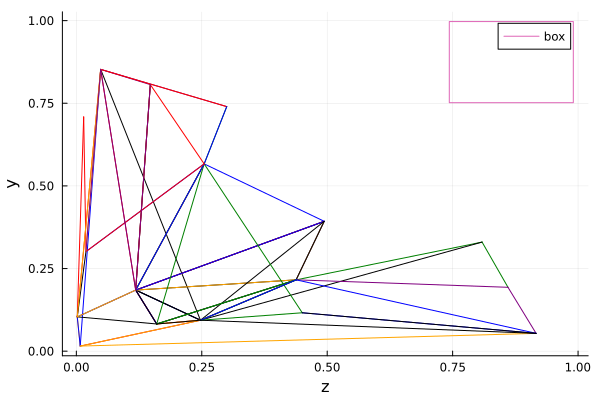

In [298]:
plot1 = Plots.plot(xlabel="x",ylabel="y")

cols = [:green,:blue,:black,:red,:orange,:purple]

for (j,simp) in enumerate(corner)
    J = j%6 + 1
    for i in 1:3
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

Plots.plot!([box[1,1],box[1,1],box[1,2],box[1,2],box[1,1]],[box[2,1],box[2,2],box[2,2],box[2,1],box[2,1]],label="box")

plot2 = Plots.plot(xlabel="z",ylabel="y")

for (j,simp) in enumerate(corner)

    J = j%6 + 1

    for i in 1:3
        Plots.plot!([simp[i,3],simp[i+1,3]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

Plots.plot!([box[3,1],box[3,1],box[3,2],box[3,2],box[3,1]],[box[2,1],box[2,2],box[2,2],box[2,1],box[2,1]],label="box")


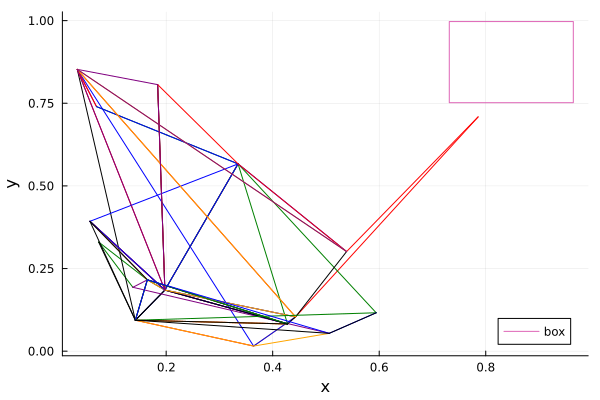

In [299]:
plot1

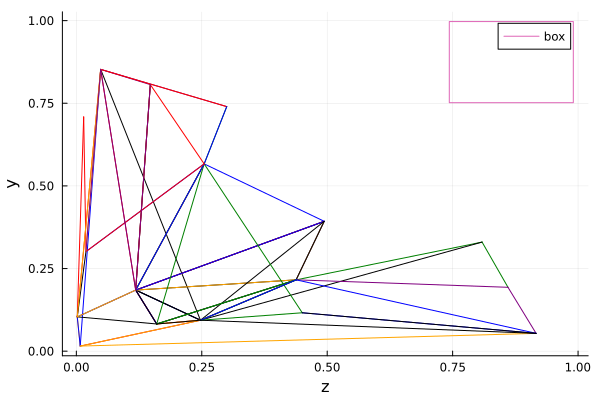

In [300]:
plot2